**If you think this notebook deserves an upvote, I'd love to have it. An upvote per view, its all I ask**
(credit to [Dan Carlin](https://twitter.com/HardcoreHistory) for coining the phrase ;-) 

---------------------------------------

This is part of a series of notebooks about practical time series methods:

* [Part 0: the basics](https://www.kaggle.com/konradb/ts-0-the-basics)
* [Part 1a: smoothing methods](https://www.kaggle.com/konradb/ts-1a-smoothing-methods)
* [Part 1b: Prophet](https://www.kaggle.com/konradb/ts-1b-prophet) 
* [Part 2: ARMA](https://www.kaggle.com/konradb/ts-2-arma-and-friends)
* [Part 3: Time series for finance](https://www.kaggle.com/konradb/ts-3-time-series-for-finance) 
* [Part 4: Sales and demand forecasting](https://www.kaggle.com/konradb/ts-4-sales-and-demand-forecasting)
* [Part 5: Automatic for the people](https://www.kaggle.com/code/konradb/ts-5-automatic-for-the-people) 
* [Part 6: Deep learning for TS - sequences](https://www.kaggle.com/konradb/ts-6-deep-learning-for-ts-sequences)
* [Part 7: Survival analysis](https://www.kaggle.com/konradb/ts-7-survival-analysis)
* [Part 8: Hierarchical time series](https://www.kaggle.com/konradb/ts-8-hierarchical-time-series)


The series is accompanied by video presentations on the YouTube channel of [Abhishek](https://www.kaggle.com/abhishek):

* [Talk 0](https://www.youtube.com/watch?v=cKzXOOtOXYY) 
* [Talk 1](https://www.youtube.com/watch?v=kAI67Sz92-s) - combining the content from parts 1a and 1b
* [Talk 2](https://www.youtube.com/watch?v=LjV5DE3KR-U) 
* [Talk 3](https://www.youtube.com/watch?v=74rDhJexmTg)
* [Talk 4](https://www.youtube.com/watch?v=RdH8zd07u2E) 
* [Talk 5](https://www.youtube.com/watch?v=wBP8Pc4Wxzs) 
* [Talk 6](https://www.youtube.com/watch?v=81AEI0tj0Kk) 
* [Talk 7](https://www.youtube.com/watch?v=m-8I_hkmz9o)
* [Talk 8](https://www.youtube.com/watch?v=7ZTarg4QYR4)


---------------------------------------


Autoregression is the simplest form of memory in a time series - so it's natural that if we go from univariate to multivariate series modeling, we would like to have something similar to AR(1) process. **V**ector **A**uto**R**egression models are this something, and in this episode we will look at them in a bit more detail; as it turns out, incorporating dependence between variables makes for a surprisingly rich framework. The notebook is split into sections where we tackle different aspects of VAR:


* [Vector Autoregression](#section-one)
* [Cointegration](#section-two)
* [VECM](#section-three)
* [Causality](#section-four)



TODO: redo ordering based on https://medium.com/towards-data-science/apply-vecm-to-see-how-changes-in-commodity-price-drive-industrial-production-in-the-united-states-e3c1b2da932d

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import pandas_datareader as web

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg

from sklearn.metrics import mean_squared_error as mse

In [2]:
# general settings
class CFG:
    data_folder = '../input/tsdata-1/'
    img_dim1 = 20
    img_dim2 = 10

# adjust the parameters for displayed figures    
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})   

In [3]:
def my_rmse(x,y):
    return(np.round( np.sqrt(mse(x,y)) ,4))

<a id="section-one"></a>
# Vector Autoregression

One of the simplest ways to model a time series is to postulate a linear relationship between present and past values (see the [ARIMA episode](https://www.kaggle.com/code/konradb/ts-2-linear-vision) for a refresher):

\begin{equation}
X_t = \theta X_{t-1} + \epsilon_t
\end{equation}

VAR models are based on the simple idea: go multivariate by replacing the scalars ($X_t$ and $\theta$ being univariate) with vectors and matrices, respectively. The math behind a little bit more involved (linear algebra), but the core idea works equally well: for a $k$-dimensional series $X_t$ we have

\begin{equation}
X_t = \sum_{i=1}^k A_i X_{t-k} + \epsilon_t
\end{equation}

where $A_i$ are $kxk$ matrices and $\epsilon_t \sim N(0, \Sigma)$.

Quick VAR summary: 

* generalize AR model to a multivariate case 

* prior knowledge: list of variables which can be hypothesized to affect each other over time

* each variable has its own equation: lagged values of target **and** lagged values of other variables $\implies$ AR(k) model. For a bivariate model:

\begin{equation}
X_{1,t} = A_{1,1} X_{1,t-1} + A_{1,2} X_{2,t-1} + \epsilon_{1,t} \\
X_{2,t} = A_{2,1} X_{1,t-1} + A_{2,2} X_{2,t-1} + \epsilon_{2,t}
\end{equation}


* bi-directional influence

* baseline (VAR in level): all the series are **stationary**

With the theoretical setup out of the way, let's take VAR for a test drive.

In [4]:
xdat = pd.read_csv('../input/historical-daily-oil-and-natural-gas-prices/oil and gas.csv', 
                  usecols= ['Symbol', 'Date', 'Close'])
xdat.head(5)

,Symbol,Date,Close
0,Brent Oil,2000-01-04,24.39
1,Brent Oil,2000-01-05,23.73
2,Brent Oil,2000-01-06,23.62
3,Brent Oil,2000-01-07,23.09
4,Brent Oil,2000-01-10,23.73


In [5]:
xdat = xdat.pivot(index='Date',columns='Symbol',values='Close')
xcols = ['Brent Oil','Heating Oil','Natural Gas']
xdat = xdat[xcols]

In [6]:
xdat.index.min(), xdat.index.max()

('2000-01-04', '2022-06-17')

<AxesSubplot:xlabel='Date'>

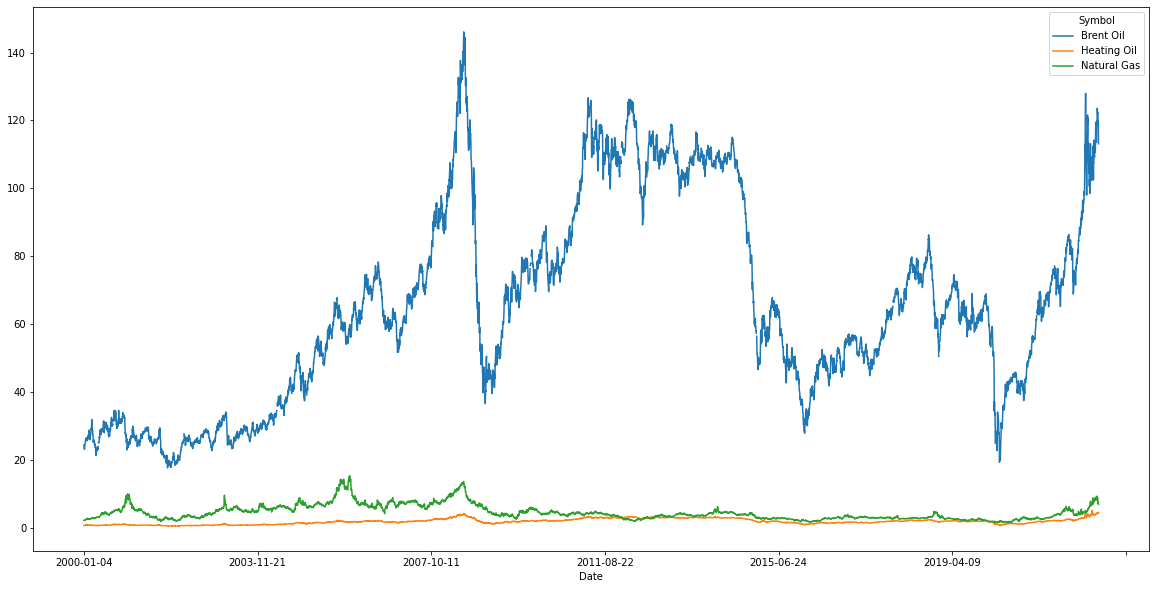

In [7]:
xdat.plot()

For now, we focus on the stationary case - so let's convert the series to returns:

In [8]:
for f in xdat.columns:
    xdat[f] = xdat[f].pct_change()

xdat.dropna(inplace = True)

<AxesSubplot:xlabel='Date'>

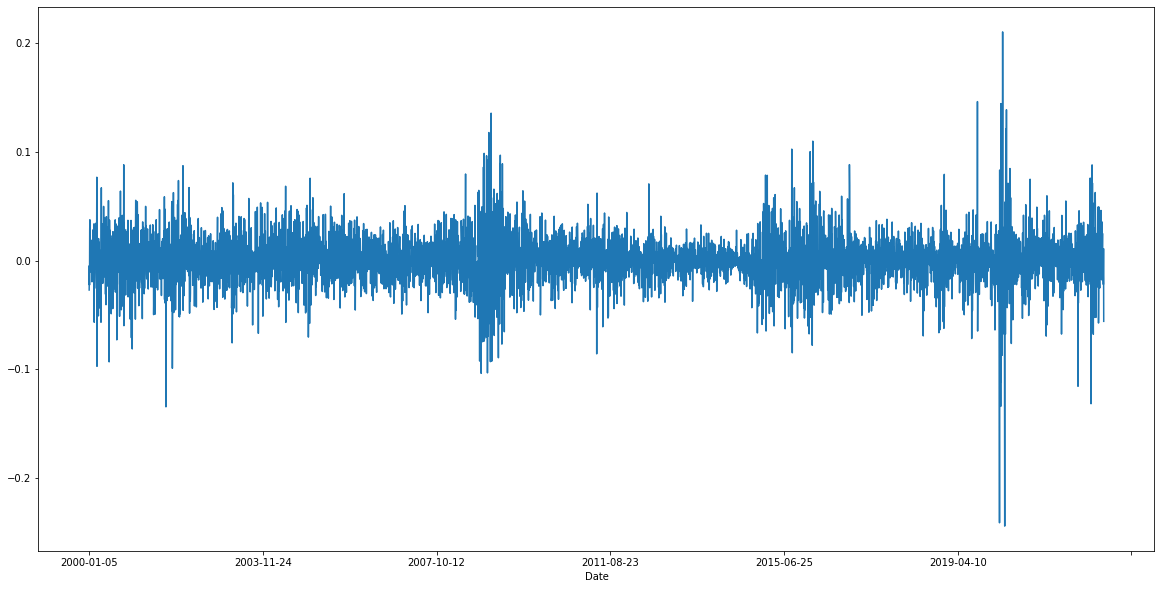

In [9]:
xdat['Brent Oil'].plot()

In [10]:
# sanity check - are the series stationary? or at least not horribly non-stationary...
for f in xdat.columns:
    
    result = adfuller(xdat[f])
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

    print('---')

ADF Statistic: -17.699900
p-value: 0.000000
---
ADF Statistic: -32.268963
p-value: 0.000000
---
ADF Statistic: -15.770113
p-value: 0.000000
---


In [11]:
# split into train and test
xtrain, xtest = xdat['2010-01-01': '2022-05-31'], xdat['2022-06-01':]
xtrain.index = pd.DatetimeIndex(xtrain.index).to_period('M')

Start with individual univariate models:

In [12]:

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None 

for (ff, xcol) in enumerate(xcols):
    
    model = AutoReg(xtrain[xcol], lags = [1]).fit()
    pred = model.forecast(xtest.shape[0])
    xerr = my_rmse(xtest[xcol].values, pred)
    xtest[xcol + ' - single'] = pred.values
    print(xcol + ' RMSE: ' + str(xerr)) 


Brent Oil RMSE: 0.0224
Heating Oil RMSE: 0.0222
Natural Gas RMSE: 0.0638


How does a multivariate model perform by comparison?

In [13]:
# fit a joint multivariate model
lag_order = 1
model1 = VAR(xtrain)
results = model1.fit(maxlags= lag_order , ic='aic')
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 07, Oct, 2022
Time:                     09:25:58
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.4923
Nobs:                     3254.00    HQIC:                  -23.5067
Log likelihood:           24418.8    FPE:                6.13305e-11
AIC:                     -23.5147    Det(Omega_mle):     6.11049e-11
--------------------------------------------------------------------
Results for equation Brent Oil
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000366         0.000394            0.930           0.352
L1.Brent Oil           0.018614         0.032329            0.576           0.565
L1.Heating Oil        -0.013430         0.034169    

In [14]:
# predict from the joint model
joint_forecast = results.forecast(xtrain.values[-lag_order:], xtest.shape[0])

pd.options.mode.chained_assignment = None 

for (ff,xcol) in enumerate(xcols):
    xtest[xcol + ' - joint'] = joint_forecast[:,ff]
     

In [15]:
# evaluate
for xc in xcols:
    print(xc + ': ')
    xerr = my_rmse(xtest[xc].values, xtest[xc + ' - single'])
    print('single: ' + str(xerr))
    xerr = my_rmse(xtest[xc].values, xtest[xc + ' - joint'])
    print('joint: ' + str(xerr))
    print('---')
    

Brent Oil: 
single: 0.0224
joint: 0.0223
---
Heating Oil: 
single: 0.0222
joint: 0.0222
---
Natural Gas: 
single: 0.0638
joint: 0.0635
---


As we can see from the metrics above, even incorporating single lag from the other variables can improve the quality of the forecast.

<a id="section-two"></a>
# Cointegration

Quick primer: 

* The VAR model is applicable if all the variables are stationary $\rightarrow$ possible loss of info about long term relationshop

* can we transform (multiple) non-stationary series so that the combination is stationary?

* (reminder) series $X$ is integrated of order $d$ $\iff$ $\Delta^d$ X is stationary (refresher: https://www.kaggle.com/code/konradb/ts-0-the-basics)

* bivariate: $X$, $Y$ $\sim$ $I(d_1)$ and $\alpha X + \beta Y \sim I(d_2)$ with $d_1 > d_2$ $\implies$ $X$ and $Y$ are **cointegrated**

In [16]:
stock = ['^RUT', '^GSPC', '^DJI', '^IXIC' ]
start = pd.to_datetime('2000-01-03')
df = web.DataReader(stock, data_source = 'yahoo', start = start)
xdat = df['Adj Close']
print(xdat.tail());

Symbols            ^RUT        ^GSPC          ^DJI         ^IXIC
Date                                                            
2022-09-30  1664.719971  3585.620117  28725.509766  10575.620117
2022-10-03  1708.869995  3678.429932  29490.890625  10815.429688
2022-10-04  1775.770020  3790.929932  30316.320312  11176.410156
2022-10-05  1762.689941  3783.280029  30273.869141  11148.639648
2022-10-06  1752.510010  3744.520020  29926.939453  11073.309570


<AxesSubplot:xlabel='Date'>

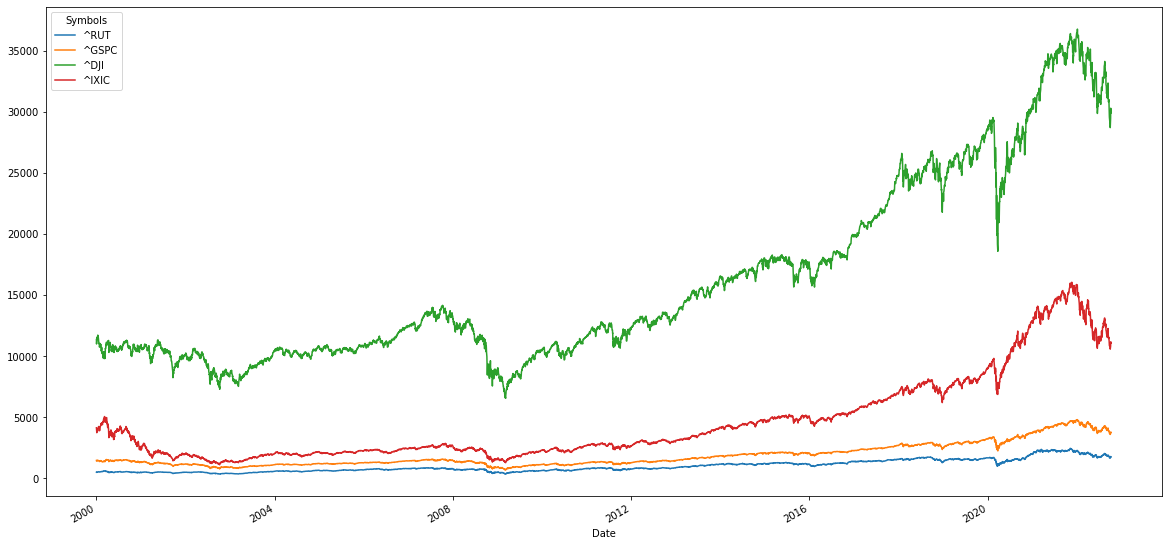

In [17]:
xdat.plot()

In [18]:
# sanity check: are any of the series stationary?
for f in xdat.columns:
    
    result = adfuller(xdat[f])
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

    print('---')


ADF Statistic: -0.676959
p-value: 0.852628
---
ADF Statistic: 0.603110
p-value: 0.987692
---
ADF Statistic: 0.214866
p-value: 0.973083
---
ADF Statistic: 0.318298
p-value: 0.978169
---


There are different methods to check for cointegrating relationships - we will go with the Johansen test:


In [19]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [20]:
res = coint_johansen(xdat, det_order = 0, k_ar_diff = 1)
res.cvm

array([[25.1236, 27.5858, 32.7172],
       [18.8928, 21.1314, 25.865 ],
       [12.2971, 14.2639, 18.52  ],
       [ 2.7055,  3.8415,  6.6349]])

If a cointegration has been established (more precisely: the null of no cointegration rejected), we can build a Vector Error Correction Model to improve on the VAR.

<a id="section-three"></a>
# Vector Error Correction


TODO: https://www.r-econometrics.com/timeseries/vecintro/

TODO: https://www.r-econometrics.com/timeseries/

TODO:
    
Vector Error Correction Model is a cointegrated VAR model. This idea of Vector Error Correction Model (VECM), which consists of a VAR model of the order p - 1 on the differences of the variables, and an error-correction term derived from the known (estimated) cointegrating relationship. Intuitively, and using the stock market example, a VECM model establishes a short-term relationship between the stock prices, while correcting with the deviation from the long-term comovement of prices. An Impulse Response Function traces the incremental effect of a 1 unit (or one standard deviation) shock in one of the variables on the future values of the other endogenous variables. Impulse Response Functions trace the incremental effect of the marketing action reflected in the shock.

https://towardsdatascience.com/vector-autoregressions-vector-error-correction-multivariate-model-a69daf6ab618

https://towardsdatascience.com/apply-vecm-to-see-how-changes-in-commodity-price-drive-industrial-production-in-the-united-states-e3c1b2da932d



- 
TODO:

This model can be applied only to variables that are cointegrated, i.e. variables that, if combined in a linear way, ended being stationary. Therefore, we need to perform a test that assess whether for each lag allowed there exist at least one combination of our variables that allows for stationarity. This model imposes additional restriction due to the existence of non-stationary but cointegrated data forms

A common example is where the individual series are first-order integrated ({\displaystyle I(1)}{\displaystyle I(1)}) but some (cointegrating) vector of coefficients exists to form a stationary linear combination of them. For instance, a stock market index and the price of its associated futures contract move through time, each roughly following a random walk. Testing the hypothesis that there is a statistically significant connection between the futures price and the spot price could now be done by testing for the existence of a cointegrated combination of the two series.




The possible presence of cointegration must be taken into account when choosing a technique to test hypotheses concerning the relationship between two variables having unit roots (i.e. integrated of at least order one).[2] The usual procedure for testing hypotheses concerning the relationship between non-stationary variables was to run ordinary least squares (OLS) regressions on data which had been differenced. This method is biased if the non-stationary variables are cointegrated.



VAR model requires stationarity of signals. However, when signals  
x
t
  and  
y
t
  are I(1) (non-stationary with the order of integration 1) and if there is a  
θ
  such that  
(
y
t
−
θ
x
t
)
  is stationary,  
x
t
  and  
y
t
  are cointegrated and a VEC model can be used.


<a id="section-four"></a>
# Causality

https://www.kaggle.com/code/ruchi798/a-tale-of-two-cities-analyzing-trends#Training-the-VAR-model


https://medium.com/@financialnoob/cointegration-based-multivariate-statistical-arbitrage-339adcbe314


https://towardsdatascience.com/vector-autoregressions-vector-error-correction-multivariate-model-a69daf6ab618


https://medium.com/@lucadonghi_25036/forecasting-macroeconomic-variables-with-multi-variate-time-series-models-afe13172ac40

https://medium.com/geekculture/vector-auto-regressive-var-models-for-multivariate-time-series-forecasting-106bb6f74add

https://medium.com/data-from-the-trenches/causal-inference-on-observational-data-its-all-about-the-assumptions-6c1d6ce5453d


https://towardsdatascience.com/the-need-for-causal-inference-4c7c612dde91


https://towardsdatascience.com/a-quick-introduction-on-granger-causality-testing-for-time-series-analysis-7113dc9420d2


https://towardsdatascience.com/inferring-causality-in-time-series-data-b8b75fe52c46#9666

https://www.kaggle.com/code/ruchi798/a-tale-of-two-cities-analyzing-trends

https://medium.com/mlearning-ai/how-i-used-statsmodels-vector-autoregression-var-to-forecast-on-multivariate-training-data-fc867eb6de8b

https://towardsdatascience.com/granger-causality-and-vector-auto-regressive-model-for-time-series-forecasting-3226a64889a6

https://towardsdatascience.com/vector-autoregressions-vector-error-correction-multivariate-model-a69daf6ab618

https://towardsdatascience.com/predicting-fang-stock-prices-ecac4ddd27c1

https://cprosenjit.medium.com/multivariate-time-series-forecasting-using-vector-autoregression-3e5c9b85e42a

https://medium.com/@jdeconomics.inquiries/cointegration-4780189df238

https://medium.com/geekculture/vector-auto-regression-for-multivariate-time-series-forecasting-9334d29591f3

https://medium.com/adventures-in-data-science/financial-data-is-non-stationary-what-does-that-mean-and-what-can-we-do-e47860bc784e

https://towardsdatascience.com/vector-auto-regression-for-multivariate-time-series-forecasting-cf5216c9ce23

https://www.machinelearningplus.com/time-series/vector-autoregression-examples-python/

https://towardsdatascience.com/cointegration-popular-methods-1-2-the-engle-granger-approach-82b6d270ddf2




